# [LangSmith Prompt Hub](https://docs.langchain.com/langsmith/manage-prompts-programmatically)
> LangSmith Prompt Hub → "프롬프트 중앙 관리 시스템"


## 사용 상황
- 프롬프트를 버전 관리하며 중앙에서 체계적으로 관리하고 싶을 때
- 팀원들과 프롬프트를 공유하고 협업할 때
- 프롬프트 변경 이력을 추적하고 이전 버전으로 되돌리고 싶을 때
- 여러 프로젝트에서 동일한 프롬프트를 재사용할 때


## 개념
- LangSmith는 LangChain에서 제공하는 프롬프트 관리 플랫폼입니다
- 프롬프트를 클라우드에 저장하고 버전 관리를 할 수 있습니다
- Python/TypeScript SDK를 통해 프로그래밍 방식으로 프롬프트를 관리할 수 있습니다
- 공개(Public) 프롬프트와 비공개(Private) 프롬프트를 구분할 수 있습니다


## 주요 기능

| 기능 | 설명 | 메서드 |
| --- | --- | --- |
| **Push** | 프롬프트 생성/업데이트 | `client.push_prompt()` |
| **Pull** | 프롬프트 가져오기 | `client.pull_prompt()` |
| **List** | 프롬프트 목록 조회 | `client.list_prompts()` |
| **Delete** | 프롬프트 삭제 | `client.delete_prompt()` |
| **Like** | 프롬프트 좋아요 | `client.like_prompt()` |


# 예제 


## 환경 설정


### [LangSmith 사이트](https://smith.langchain.com/)에 접속하여 회원가입

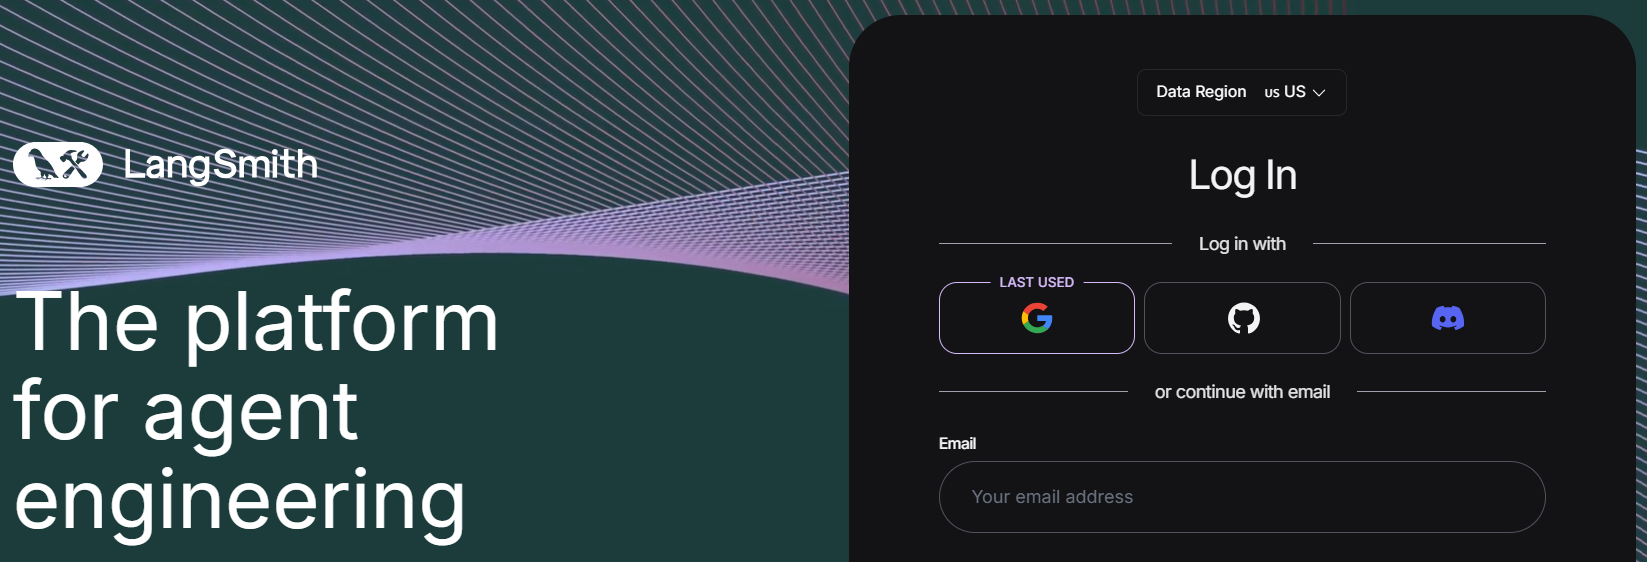

### LangSmith API Key 설정
- `Settings > API Keys > Create API Key`에서 API 키 발급


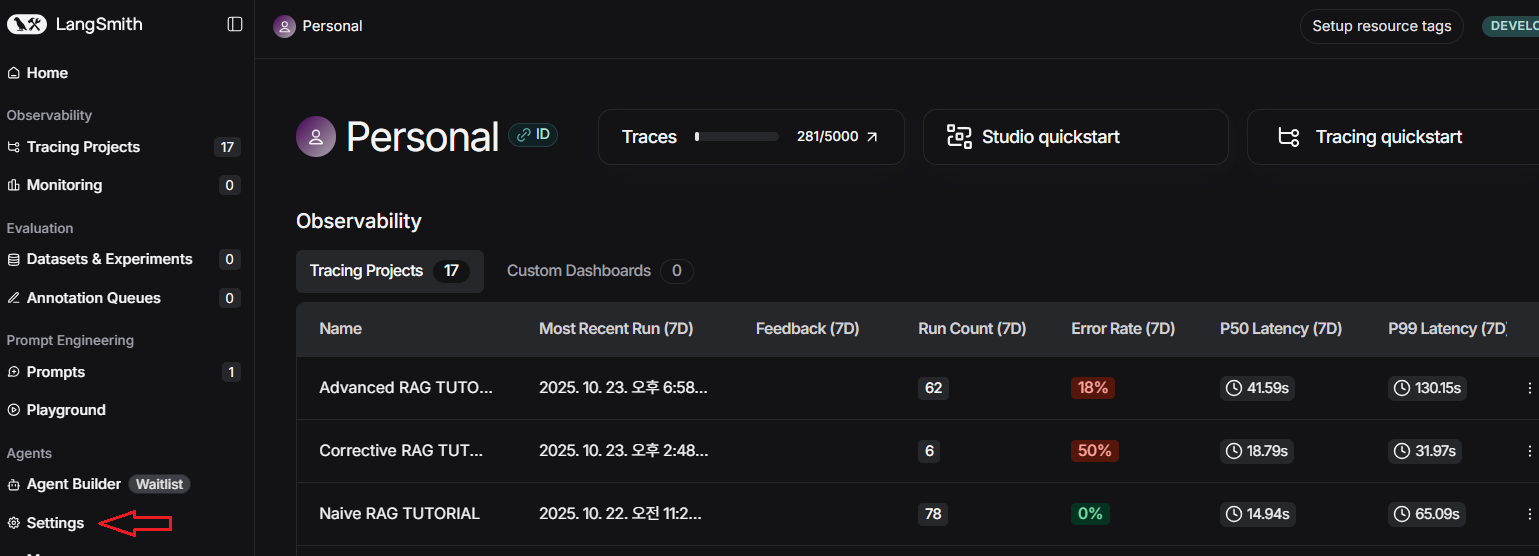

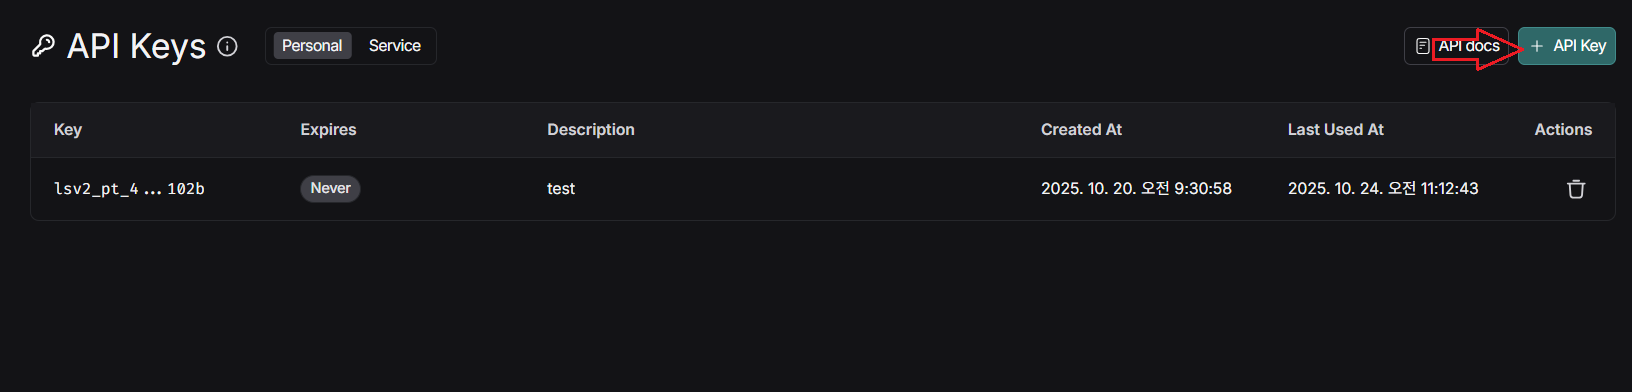

### `.env` 파일에 API 키 저장

In [1]:
from dotenv import load_dotenv

# 환경 변수 로드
load_dotenv()

True

In [2]:
import os

# API 키 확인
api_key = os.getenv("LANGSMITH_API_KEY")
if api_key:
    print("LangSmith API 키가 설정되었습니다.")
else:
    print("LangSmith API 키가 없습니다. .env 파일을 확인해주세요.")


LangSmith API 키가 설정되었습니다.


### LangSmith Client 생성


In [3]:
from langsmith import Client

# LangSmith 클라이언트 생성
client = Client()


## Push Prompt (프롬프트 업로드)


### 기본 프롬프트 업로드


In [4]:
from langchain_core.prompts import ChatPromptTemplate

# 프롬프트 템플릿 생성
prompt = ChatPromptTemplate.from_template(
    template="당신은 {topic}에 대한 전문가입니다. {topic}에 대해 간단하게 설명해주세요."
)


In [5]:
prompt.input_variables

['topic']

In [6]:
# LangSmith에 프롬프트 업로드
url = client.push_prompt(
    prompt_identifier="topic-explainer",  # 프롬프트 이름
    object=prompt,  # 업로드할 프롬프트 객체
    is_public=False # 공개 유무 
)

print(f"프롬프트가 업로드되었습니다: {url}")

프롬프트가 업로드되었습니다: https://smith.langchain.com/prompts/topic-explainer/b42a6a8e?organizationId=9b0045e0-4ff2-5e75-ab7d-5e8ee81fb8d1


#### [LangSmith에서 확인](https://smith.langchain.com/) 

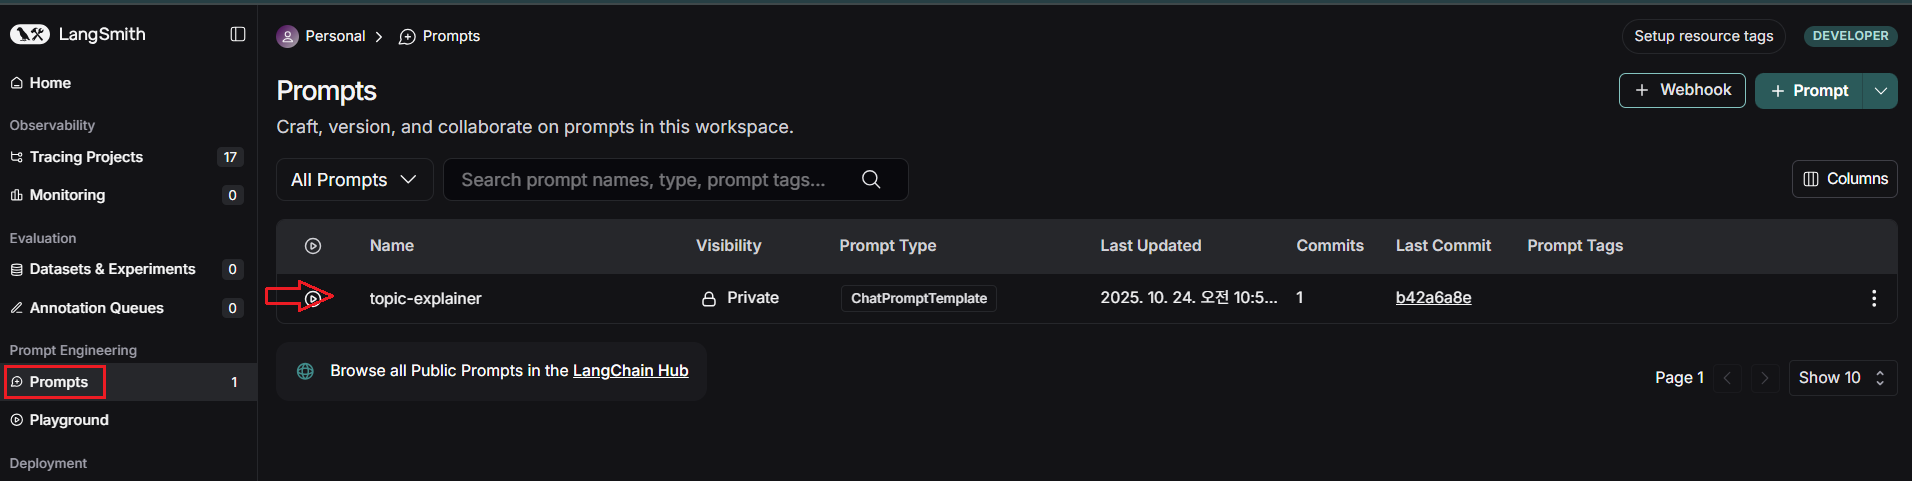

### 모델과 함께 프롬프트 업로드
- 프롬프트와 모델 설정을 함께 저장할 수 있습니다
- 프롬프트를 불러올 때 모델 설정도 함께 가져올 수 있습니다


In [7]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_groq import ChatGroq

# 모델 생성
model = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.1
)

In [8]:
# 프롬프트 생성
prompt = ChatPromptTemplate.from_template(
    "{topic}에 대한 재미있는 농담을 하나 들려주세요."
)

In [9]:
# 프롬프트와 모델을 체인으로 연결
chain = prompt | model

In [10]:
# LangSmith에 업로드
url = client.push_prompt(
    prompt_identifier="joke-generator-with-model",  # 프롬프트 이름
    object=chain,
    is_public=False # 공개 유무
)

print(f"프롬프트와 모델이 함께 업로드되었습니다: {url}")


프롬프트와 모델이 함께 업로드되었습니다: https://smith.langchain.com/prompts/joke-generator-with-model/5fed0e80?organizationId=9b0045e0-4ff2-5e75-ab7d-5e8ee81fb8d1


#### [LangSmith에서 확인](https://smith.langchain.com/) 

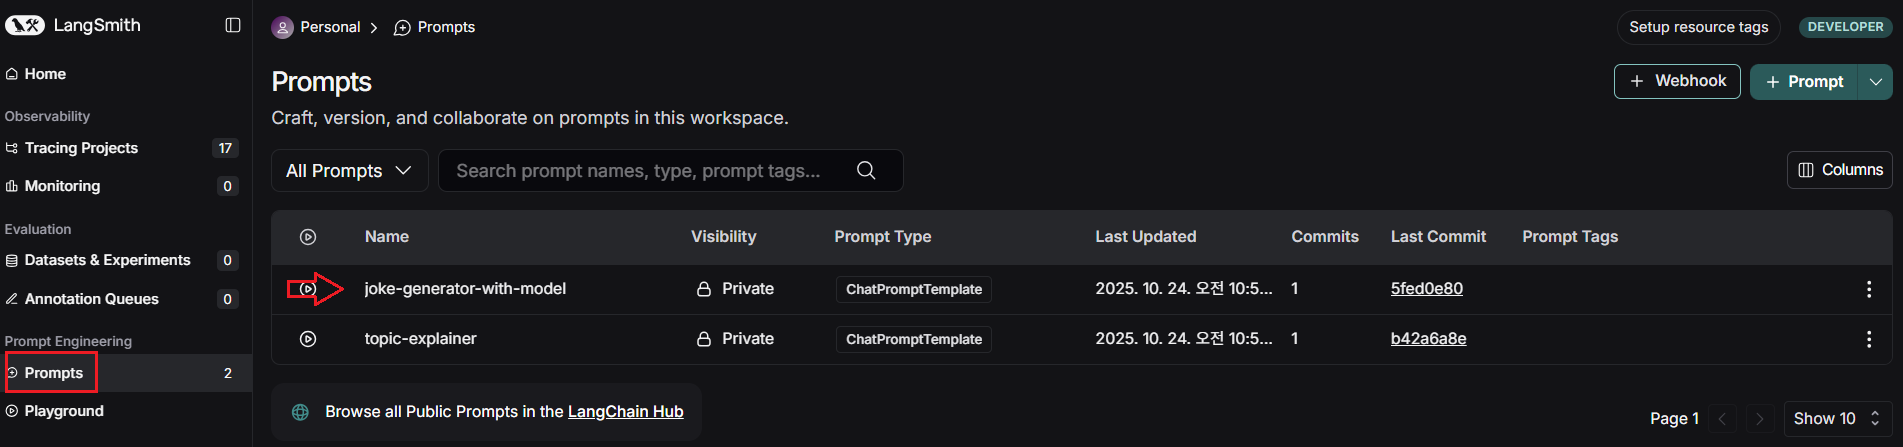

## Pull Prompt (프롬프트 가져오기)


### 기본 프롬프트 가져오기


In [11]:
# 프롬프트 가져오기
pulled_prompt = client.pull_prompt("topic-explainer")

print("프롬프트를 가져왔습니다:")
print(pulled_prompt)


프롬프트를 가져왔습니다:
input_variables=['topic'] input_types={} partial_variables={} metadata={'lc_hub_owner': '-', 'lc_hub_repo': 'topic-explainer', 'lc_hub_commit_hash': 'b42a6a8e76d665677bfacd2e21c712f57b24c97274c4ac161e29b604faa4143c'} messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['topic'], input_types={}, partial_variables={}, template='당신은 {topic}에 대한 전문가입니다. {topic}에 대해 간단하게 설명해주세요.'), additional_kwargs={})]


In [12]:
pulled_prompt.input_variables

['topic']

### 가져온 프롬프트 사용하기


In [13]:
from langchain_ollama import ChatOllama

# 로컬 모델 생성
model = ChatOllama(
    model="gemma3:4b",
    temperature=0.1
)

In [14]:
# 프롬프트와 모델을 체인으로 연결
chain = pulled_prompt | model

In [15]:
# 체인 실행
response = chain.invoke({"topic": "양자컴퓨팅"})
print(response.content)


안녕하세요! 양자컴퓨팅 전문가로서 양자컴퓨팅에 대해 쉽고 명확하게 설명해 드리겠습니다.

**양자컴퓨팅이란 무엇일까요?**

기존의 컴퓨터는 0 또는 1의 비트(bit)를 사용하여 정보를 저장하고 처리합니다. 반면, 양자컴퓨터는 양자역학의 원리를 이용하여 정보를 처리합니다. 핵심은 **큐비트(qubit)**라는 개념입니다.

**큐비트(Qubit)란 무엇일까요?**

*   **중첩(Superposition):** 큐비트는 0과 1의 상태를 동시에 가질 수 있습니다. 마치 동전이 공중에서 돌고 있을 때 앞면과 뒷면이 동시에 보이는 것과 같습니다. 이러한 중첩 덕분에 양자컴퓨터는 여러 가능성을 동시에 탐색하여 특정 문제를 훨씬 빠르게 해결할 수 있습니다.
*   **얽힘(Entanglement):** 큐비트들은 서로 얽혀있을 수 있습니다. 얽힌 큐비트 중 하나의 상태를 측정하면 다른 큐비트의 상태가 즉시 결정됩니다. 이는 양자컴퓨터의 연산 능력을 더욱 향상시키는 중요한 요소입니다.

**양자컴퓨터의 작동 방식**

1.  **문제 정의:** 해결하고자 하는 문제를 양자컴퓨터가 이해할 수 있는 형태로 정의합니다.
2.  **큐비트 초기화:** 큐비트를 특정 상태로 초기화합니다.
3.  **양자 알고리즘 적용:** 양자 알고리즘(예: 쇼어 알고리즘, 그로버 알고리즘)을 사용하여 큐비트를 조작하고 연산을 수행합니다.
4.  **측정:** 큐비트의 상태를 측정하여 결과를 얻습니다. (측정은 큐비트의 중첩 상태를 붕괴시키므로, 결과는 확률적으로 결정됩니다.)

**양자컴퓨터의 활용 분야**

*   **신약 개발:** 분자 시뮬레이션을 통해 신약 후보 물질을 빠르게 탐색하고 개발 기간을 단축합니다.
*   **재료 과학:** 새로운 소재의 특성을 예측하고 설계합니다.
*   **금융:** 복잡한 금융 상품의 가격을 결정하고 위험을 관리합니다.
*   **암호 해독:** 현재 사용되는 암호 체계를 깨뜨릴 수 있는 잠재력을 가지고 있습니다. (반대로 양자 암호 기술 개발도 

### 모델과 함께 가져오기
- `include_model=True` 옵션을 사용하면 프롬프트와 모델을 함께 가져올 수 있습니다


In [16]:
# 프롬프트와 모델을 함께 가져오기
chain = client.pull_prompt(
    prompt_identifier="joke-generator-with-model",
    include_model=True
)

In [17]:
chain

ChatPromptTemplate(input_variables=['topic'], input_types={}, partial_variables={}, metadata={'lc_hub_owner': '-', 'lc_hub_repo': 'joke-generator-with-model', 'lc_hub_commit_hash': '5fed0e8059209e5b69a273cd3fdf40f5847ad224aac11e50d804113bee1cd631'}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['topic'], input_types={}, partial_variables={}, template='{topic}에 대한 재미있는 농담을 하나 들려주세요.'), additional_kwargs={})])
| ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x11b882850>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x11b883250>, model_name='openai/gpt-oss-120b', temperature=0.1, model_kwargs={}, groq_api_key=SecretStr('**********'))

In [18]:
# 바로 사용 가능
response = chain.invoke({"topic": "프로그래머"})
print(response.content)


프로그래머가 술집에 들어갔어요.

바텐더가 물었죠. “뭐 마실래요?”

프로그리머가 대답했어요. “버그가 없는 **코드** 한 잔 주세요.  
그럼 **디버깅**은 나중에 할게요!” 😄


### [공개 프롬프트 가져오기](https://smith.langchain.com/hub)
- LangChain Hub의 공개 프롬프트를 가져올 때는 작성자의 핸들을 포함해야 합니다


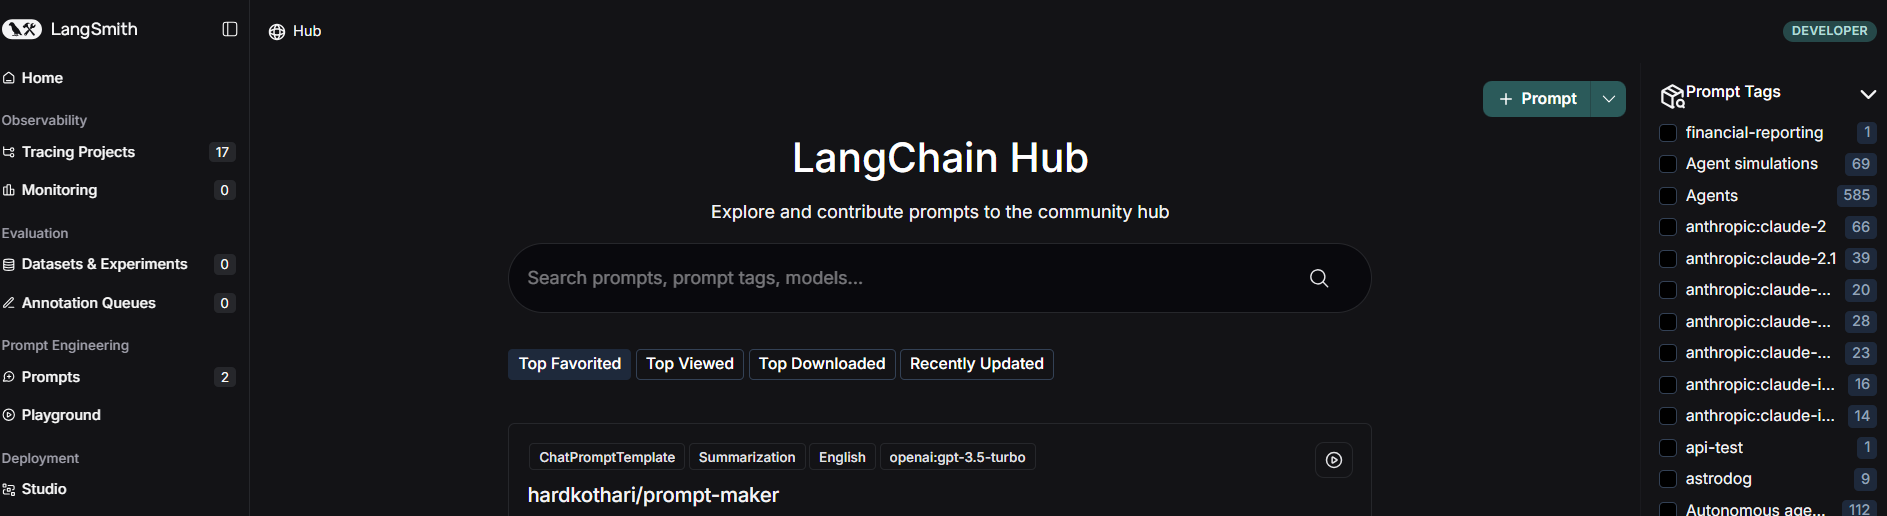

In [19]:
# 공개 프롬프트 가져오기 (작성자/프롬프트명)
public_prompt = client.pull_prompt("heun0420/ko-summary")

public_prompt


ChatPromptTemplate(input_variables=['context'], input_types={}, partial_variables={}, metadata={'lc_hub_owner': 'heun0420', 'lc_hub_repo': 'ko-summary', 'lc_hub_commit_hash': '7286e08b7219379321bcc7362f29246b29aa43923a2de8411e2935191bf4969b'}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context'], input_types={}, partial_variables={}, template='주어진 내용을 바탕으로 문장을 요약하세요. \n    답변은 반드시 한글로 작성하세요\n    #Context:\n    {context}\n    #Summary:\n    '), additional_kwargs={})])

In [20]:
public_prompt.input_variables

['context']

In [21]:
print(public_prompt.messages[0].prompt.template)

주어진 내용을 바탕으로 문장을 요약하세요. 
    답변은 반드시 한글로 작성하세요
    #Context:
    {context}
    #Summary:
    


## List Prompts (프롬프트 목록 조회)


### 모든 프롬프트 조회


In [22]:
# 내 워크스페이스의 모든 프롬프트 조회
prompts = client.list_prompts()

In [23]:
print("=== 프롬프트 목록 ===")
for prompt in prompts.repos:
    print(f"- {prompt.repo_handle}")


=== 프롬프트 목록 ===
- joke-generator-with-model
- topic-explainer
- software_engineer-unasp
- soomgo_portfolio_write_onestep_ver_3
- ocr_generator
- databricks-engineer
- guardrails_check_metadata_list
- guardrails_analyze_user_request
- student-cer-evaluation
- retrieval-qa-chat
- v3_score_answers_to_examiner_questions
- v3_generate_questions_to_start_exam
- recipe
- market_outline_optimizer
- sql-server-index-analysis
- construct_json_from_table_default
- eval_pa_chatbot_production_classify_f3ce8c76
- record_recipe_prompt
- create-cv-draft
- create-cv-outline
- low_code_cv_outline
- data_engineering_cv_outline
- integration_developer_cv_outline
- summarize-cv
- cv-outline-from-aggregation
- summarize-vacancy-prompt
- pavan-n-patil_pyspark
- llm-doc-translator
- eval_test_answer_relevance_cf374e3d
- eval_test_retreival_relevance_cdc4682b
- eval_test_groundness_ed44e897
- hierarchical-clustering-semantic-contexts-educational-materials
- podcastfy_longform
- podcast_rewriter
- contextual-se

### 검색 조건으로 프롬프트 조회


In [24]:
# 특정 키워드를 포함한 비공개 프롬프트만 조회
filtered_prompts = client.list_prompts(
    query="joke",       # 검색 키워드
    is_public=False     # 비공개 프롬프트만
)

In [25]:
print("=== 'joke'를 포함한 비공개 프롬프트 ===")
for prompt in filtered_prompts.repos:
    print(f"- {prompt.repo_handle}")


=== 'joke'를 포함한 비공개 프롬프트 ===
- joke-generator-with-model


## Delete Prompt (프롬프트 삭제)


### topic-explainer

- 삭제하기전 프롬프트 확인 

In [26]:
client.list_prompts(
    query="topic-explainer",       # 검색 키워드
    is_public=False     # 비공개 프롬프트만
)

ListPromptsResponse(repos=[Prompt(repo_handle='topic-explainer', description='', readme='', id='f8657ee5-b1fc-45cf-af8b-85e26aca65ec', tenant_id='9b0045e0-4ff2-5e75-ab7d-5e8ee81fb8d1', created_at=datetime.datetime(2025, 10, 25, 11, 1, 56, 436264), updated_at=datetime.datetime(2025, 10, 25, 11, 1, 57, 353548), is_public=False, is_archived=False, tags=['ChatPromptTemplate'], original_repo_id=None, upstream_repo_id=None, owner=None, full_name='topic-explainer', num_likes=0, num_downloads=1, num_views=2, liked_by_auth_user=False, last_commit_hash='b42a6a8e76d665677bfacd2e21c712f57b24c97274c4ac161e29b604faa4143c', num_commits=1, original_repo_full_name=None, upstream_repo_full_name=None)], total=1)

- 프롬프트 삭제 

In [27]:
# 프롬프트 삭제 (주의: 실제로 삭제됩니다!)
client.delete_prompt("topic-explainer")

- 프롬프트를 삭제하였기 때문에 조회하지 못함 

In [28]:
client.list_prompts(
    query="topic-explainer",       # 검색 키워드
    is_public=False     # 비공개 프롬프트만
)

ListPromptsResponse(repos=[], total=0)

### joke-generator-with-model

- 삭제하기전 프롬프트 확인 

In [29]:
client.list_prompts(
    query="joke-generator-with-model",       # 검색 키워드
    is_public=False     # 비공개 프롬프트만
)

ListPromptsResponse(repos=[Prompt(repo_handle='joke-generator-with-model', description='', readme='', id='b5b3b37c-b85b-4d8b-8be7-928ffdc92d69', tenant_id='9b0045e0-4ff2-5e75-ab7d-5e8ee81fb8d1', created_at=datetime.datetime(2025, 10, 25, 11, 3, 35, 735516), updated_at=datetime.datetime(2025, 10, 25, 11, 3, 36, 730410), is_public=False, is_archived=False, tags=['ChatPromptTemplate'], original_repo_id=None, upstream_repo_id=None, owner=None, full_name='joke-generator-with-model', num_likes=0, num_downloads=1, num_views=2, liked_by_auth_user=False, last_commit_hash='5fed0e8059209e5b69a273cd3fdf40f5847ad224aac11e50d804113bee1cd631', num_commits=1, original_repo_full_name=None, upstream_repo_full_name=None)], total=1)

- 프롬프트 삭제 

In [30]:
# 프롬프트 삭제 (주의: 실제로 삭제됩니다!)
client.delete_prompt("joke-generator-with-model")


- 프롬프트를 삭제하였기 때문에 조회하지 못함 

In [31]:
client.list_prompts(
    query="joke-generator-with-model",       # 검색 키워드
    is_public=False     # 비공개 프롬프트만
)

ListPromptsResponse(repos=[], total=0)